# Hyperparameter sweep for AxBench

In [4]:
import pandas as pd
from pathlib import Path

cfg = "2b_l10"
# cfg = "2b_l20"
# cfg = "9b_l20"
# cfg = "q25_32b_l32"
# cfg = "27b_l21"
# cfg = "g3_12b_l22"

positions = "all"
# positions = "f2+l2"
# positions = "all_prompt"
# positions = "f4+l4"

obj = "lang"
# obj = "simpo"
# obj = "bisimpo"

batch_size_list = [3, 6, 12]
epochs_list = [6, 12, 18, 24, 30]
vector_init_size_list = [1, 8, 16]
vector_lr_list = ['4e-2', '8e-2']
factor_lr_list = ['1e-2', '1e-1', '1', '10', '20', '40']
factor_init_size_list = [1, 2, 4, 8, 16]

# output_base_dir = Path("/mnt/data/byt", "reft_data", "hp_sweep", cfg)
output_base_dir = Path("/home/byt", "reft_data", "hp_sweep", cfg)
# output_base_dir = Path("/mnt/data/byt", "reft_data", "hp_sweep_clip_grad", cfg)


In [5]:
from collections import defaultdict
import itertools
import numpy as np

def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1/s for s in scores)


def get_overall_score_concept_df(eval_df):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()

res_df = defaultdict(list)

for (
    k,
    batch_size,
    epochs,
    vector_lr,
    vector_init,
    factor_lr,
    factor_init,
) in itertools.product(
    ("add_free", "pref"),
    batch_size_list,
    epochs_list,
    vector_lr_list,
    vector_init_size_list,
    factor_lr_list,
    factor_init_size_list,
):
    for concept_id in range(3):
        eval_path = (
            output_base_dir
            / f"outputs_{k}"
            / f"{positions}"
            / obj
            / f"b={batch_size}_e={epochs}_vlr={vector_lr}_vinit={vector_init}_flr={factor_lr}_finit={factor_init}"
            / f"{concept_id}"
            / "eval.parquet"
        )
        if not eval_path.exists():
            continue
        
        eval_df = pd.read_parquet(eval_path)
        overall_score = get_overall_score_concept_df(eval_df)
        concept_score = eval_df["concept_score"].mean()
        instruct_score = eval_df["relevance_score"].mean()
        fluency_score = eval_df["fluency_score"].mean()

        res_df["concept_id"].append(concept_id)
        res_df["method"].append(k)
        res_df["objective"].append(obj)
        res_df["positions"].append(positions)

        res_df["batch_size"].append(batch_size)
        res_df["epochs"].append(epochs)
        res_df["factor_lr"].append(factor_lr)
        res_df["factor_init"].append(factor_init)
        res_df["vector_lr"].append(vector_lr)
        res_df["vector_init"].append(vector_init)

        res_df["overall_score"].append(overall_score)
        res_df["concept_score"].append(concept_score)
        res_df["instruct_score"].append(instruct_score)
        res_df["fluency_score"].append(fluency_score)

res_df = pd.DataFrame(res_df)
res_df["method"] = res_df["method"].replace(
    ["add_free", "clamp_free", "pref"], ["AddInv", "ClampInv", "RePS"]
)
res_df


,concept_id,method,objective,positions,batch_size,epochs,factor_lr,factor_init,vector_lr,vector_init,overall_score,concept_score,instruct_score,fluency_score
0,0,AddInv,lang,all,12,12,1e-1,1,4e-2,1,0.72,1.1,0.9,0.9
1,1,AddInv,lang,all,12,12,1e-1,1,4e-2,1,0.65,1.2,0.9,1.1
2,2,AddInv,lang,all,12,12,1e-1,1,4e-2,1,1.16,1.6,1.2,1.0
3,0,AddInv,lang,all,12,12,1e-1,2,4e-2,1,0.44,1.2,0.5,1.0
4,1,AddInv,lang,all,12,12,1e-1,2,4e-2,1,1.15,1.2,1.5,1.0
5,2,AddInv,lang,all,12,12,1e-1,2,4e-2,1,1.04,1.3,1.3,1.1
6,0,AddInv,lang,all,12,12,1e-1,4,4e-2,1,0.52,1.0,0.6,1.0
7,1,AddInv,lang,all,12,12,1e-1,4,4e-2,1,0.89,1.3,0.9,1.0
8,2,AddInv,lang,all,12,12,1e-1,4,4e-2,1,0.88,1.6,0.8,1.0
9,0,AddInv,lang,all,12,12,1e-1,8,4e-2,1,0.00,1.0,0.0,0.1


In [6]:
score_type = "overall"
# score_type = "concept"
# score_type = "instruct"

s = res_df.groupby(
    [
        "method",
        "positions",
        "objective",
        "batch_size",
        "epochs",
        "vector_init",
        "vector_lr",
        "factor_init",
        "factor_lr",
    ]
)[["overall_score", "concept_score", "instruct_score", "fluency_score"]].mean()
s.sort_values(
    ["overall_score", "concept_score", "instruct_score", "fluency_score"], ascending=False
).head(10)


overall_score  \
method positions objective batch_size epochs vector_init vector_lr factor_init factor_lr                  
AddInv all       lang      12         12     1           4e-2      2           1               1.033333   
                                                                   1           1               0.966667   
                                                                   2           1e-1            0.876667   
                                                                   1           1e-1            0.843333   
                                                                   4           1e-1            0.763333   
                                                                               1               0.596667   
                                                                   8           1e-1            0.000000   
                                                                               1               0.000000   

                                                                                          concept_score  \
method positions objective batch_size epochs vector_init vector_lr factor_init factor_lr                  
AddInv all       lang      12         12     1           4e-2      2           1               1.300000   
                                                                   1           1               1.166667   
                                                                   2           1e-1            1.233333   
                                                                   1           1e-1            1.300000   
                                                                   4           1e-1            1.300000   
                                                                               1               1.266667   
                                                                   8           1e-1            1.000000   
                                                                               1               1.000000   

                                                                                          instruct_score  \
method positions objective batch_size epochs vector_init vector_lr factor_init factor_lr                   
AddInv all       lang      12         12     1           4e-2      2           1                1.300000   
                                                                   1           1                1.333333   
                                                                   2           1e-1             1.100000   
                                                                   1           1e-1             1.000000   
                                                                   4           1e-1             0.766667   
                                                                               1                0.666667   
                                                                   8           1e-1             0.033333   
                                                                               1                0.033333   

                                                                                          fluency_score  
method positions objective batch_size epochs vector_init vector_lr factor_init factor_lr                 
AddInv all       lang      12         12     1           4e-2      2           1               1.033333  
                                                                   1           1               1.100000  
                                                                   2           1e-1            1.033333  
                                                                   1           1e-1            1.000000  
                                                                   4           1e-1            1.000000  
                                                                               1               0.966667  
                   

In [ ]:
res_df[
    (res_df["epochs"] == 12)
    & (res_df["batch_size"] == 6)
    & (res_df["vector_lr"] == "8e-2")
    & (res_df["vector_init"] == 8)
    & (res_df["factor_init"] == 4)
    & (res_df["factor_lr"] == "1")
]


,concept_id,method,objective,positions,batch_size,epochs,factor_lr,factor_init,vector_lr,vector_init,overall_score,concept_score,instruct_score,fluency_score
18,0,AddInv,simpo,f2+l2,6,12,1,4,8e-2,8,1.10,1.0,1.4,1.1
19,1,AddInv,simpo,f2+l2,6,12,1,4,8e-2,8,1.25,1.3,1.5,1.2
20,2,AddInv,simpo,f2+l2,6,12,1,4,8e-2,8,1.21,1.4,1.8,1.0


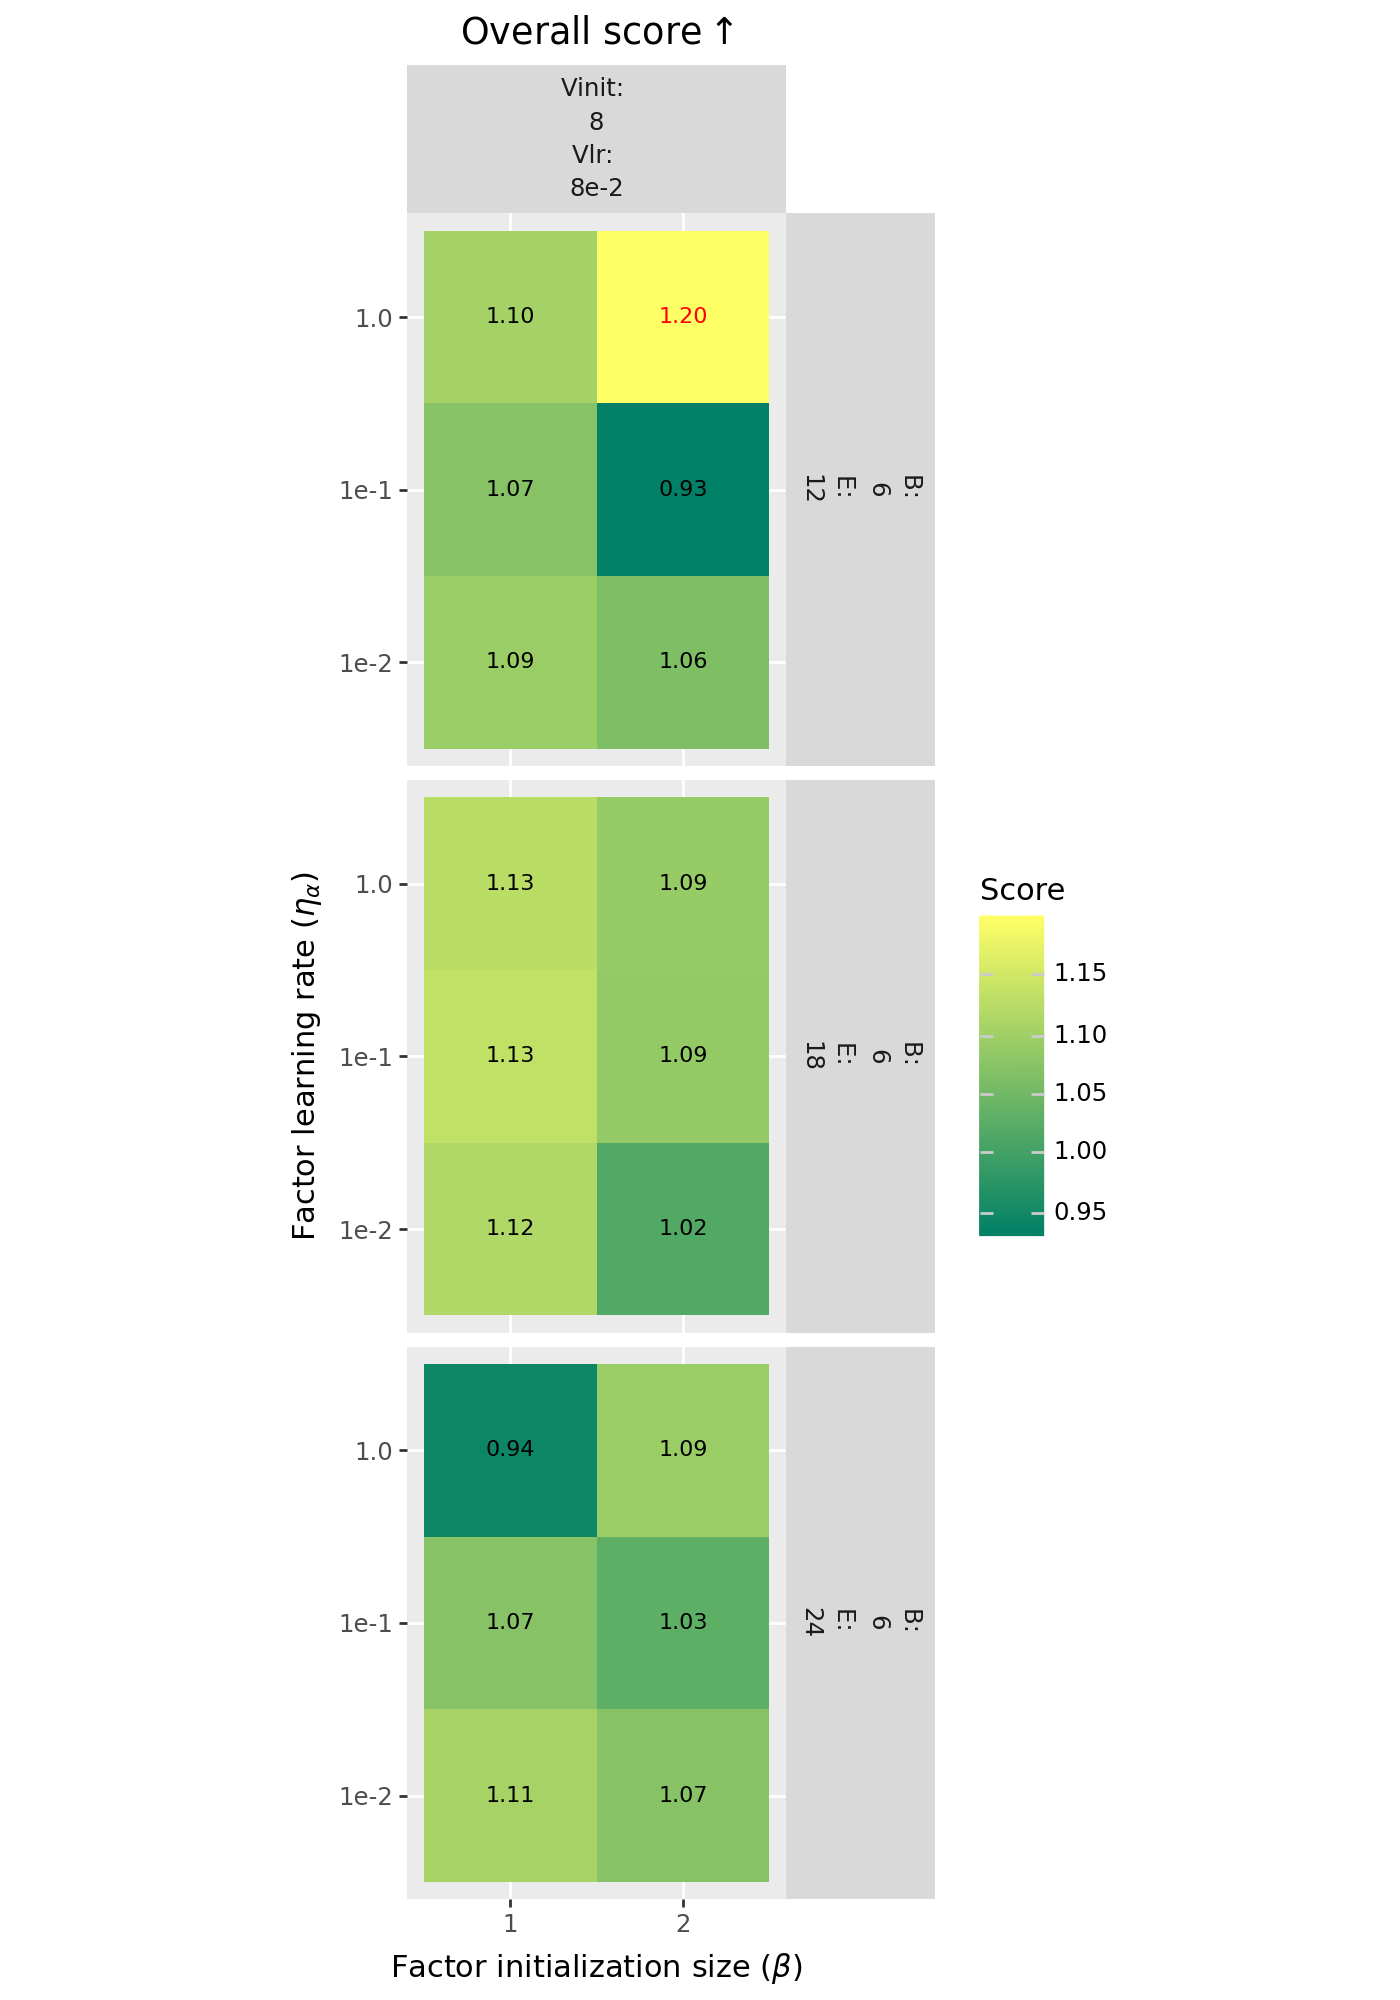

In [41]:
# Show scores of methods side-by-side

from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    labs,
    theme,
    scale_y_discrete,
    coord_equal,
    scale_fill_continuous,
    facet_grid,
    scale_color_manual,
)


score_type = "overall"
# score_type = "concept"

plot_df = (
    res_df.groupby(
        [
            "method",
            "objective",
            "batch_size",
            "epochs",
            "vector_init",
            "vector_lr",
            "factor_lr",
            "factor_init",
        ]
    )
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)

plot_df["text"] = plot_df[f"{score_type}_score"].apply(lambda x: f"{x:.2f}")
# plot_df['text'] = plot_df[f'{score_type}_score'].apply(lambda x: f"{x:.2f}" if x > 0.77 else "")

text_colors = []
for _, row in plot_df.iterrows():
    if (
        abs(
            row[f"{score_type}_score"]
            - plot_df.groupby("method")[f"{score_type}_score"].max()[row["method"]]
        )
        < 1e-3
    ):
        text_colors.append("red")
    else:
        text_colors.append("black")
plot_df["text_color"] = text_colors


plot_df["factor_lr"] = plot_df["factor_lr"].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

plot = (
    ggplot(plot_df, aes(x="factor_init", y="factor_lr", fill=f"{score_type}_score"))
    + facet_grid("'B: ' + batch_size + 'E: ' + epochs ~ 'Vinit: ' + vector_init + 'Vlr: ' + vector_lr")
    + geom_tile()
    + geom_text(aes(label="text", color="text_color"), size=8)
    + scale_color_manual({"black": "black", "red": "red"}, guide=None)
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Score",
        title=f"{score_type.capitalize()} score$\\uparrow$",
    )
    + theme(figure_size=(7, 10))
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    + scale_fill_continuous("summer")
    + coord_equal()
)

plot
